# Budsjettmodell — Smart Energistyring (V2G/V2H)

Denne notebooken modellerer driftsbudsjett og inntekter for en oppstartsbedrift som utvikler et styringssystem for energilagring via elbilbatterier.

## Tofasemodell
- **Fase 1 (Early Adopter):** Subsidiert hardware, inntekter fra abonnement. Bygger nettverket.
- **Fase 2 (Nettjenester):** Når kritisk masse (~150 enheter) → kan tilby frekvensreserver, peak shaving etc. til strømnettet.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Parametere — Juster disse!

Alle nøkkelantakelser samlet på ett sted. Endre verdier her og kjør hele notebooken på nytt for å se effekten.

In [2]:
# ============================================================
# PARAMETERE — ENDRE DISSE FOR Å UTFORSKE SCENARIOER
# ============================================================

# --- Produkt & prising ---
MATERIALKOST_START = 1200        # kr per enhet, tidlig produksjon
MATERIALKOST_VOLUM = 800         # kr per enhet, etter volum (>150 enheter kumulativt)
EARLY_ADOPTER_PRIS = 1250        # salgspris hardware, early adopter fase
NORMAL_PRIS = 4000               # salgspris hardware, etter early adopter
EARLY_ADOPTER_GRENSE = 150       # antall enheter i early adopter-programmet

# --- Abonnement ---
ABONNEMENT_MND = 149             # kr per bruker per måned
# Alternativ: sett til 0 og bruk kun revenue share

# --- Nettjenester (Fase 2) ---
NETT_TERSKEL_ENHETER = 150       # enheter nødvendig for å tilby nettjenester
TILGJENGELIGHET = 0.50           # andel enheter plugget inn til enhver tid
KWH_PER_ENHET = 15               # tilgjengelig kWh per enhet (20-80% av ~60kWh batteri)
NETT_INNTEKT_PR_KWH_AAR = 50    # kr per kWh tilgjengelig kapasitet per år (grovt estimat)
REVENUE_SHARE_KUNDE = 0.70       # andel av nettjeneste-inntekt som går til kunden
REVENUE_SHARE_SELSKAP = 0.30     # andel selskapet beholder

# --- Salgsvekst (enheter solgt per kvartal) ---
# 12 kvartaler: [Q1Y1, Q2Y1, ..., Q4Y3]
ENHETER_SOLGT = [
    5,   10,  15,  20,     # År 1: Lansering, tidlig salg (50 enheter)
    25,  30,  35,  40,     # År 2: Vekst, nærmer seg terskel (130 enheter kumulativt -> 180)
    45,  50,  55,  60,     # År 3: Etablert, nettjenester aktive (210 enheter -> 390 totalt)
]

# --- Faste kostnader per kvartal ---
ANTALL_ANSATTE = 3
KVARTALSLONN_PR_ANSATT = 132_500  # ~530k/år, litt under markedslønn

# Kontorplass (NTNU Spark/Accel i år 1, deretter leie)
KONTOR_PR_KVARTAL = [
    0, 0, 0, 0,               # År 1: Gratis via NTNU innovasjonsprogram
    15_000, 15_000, 15_000, 15_000,  # År 2: Lav leie
    25_000, 25_000, 25_000, 25_000,  # År 3: Litt større lokaler
]

# Sky/infrastruktur (Azure, API-er, etc)
SKY_PR_KVARTAL = [
    5_000, 5_000, 7_500, 7_500,       # År 1
    10_000, 10_000, 12_500, 12_500,    # År 2
    15_000, 15_000, 15_000, 15_000,    # År 3
]

# Markedsføring
MARKED_PR_KVARTAL = [
    30_000, 40_000, 30_000, 20_000,    # År 1: Lansering, høyere tidlig
    25_000, 25_000, 20_000, 20_000,    # År 2
    20_000, 15_000, 15_000, 15_000,    # År 3: Mer organisk vekst
]

# Regnskap/revisjon/bank
REGNSKAP_PR_KVARTAL = 10_000

# Forsikring (bedrift, ikke drone-relatert)
FORSIKRING_PR_KVARTAL = 5_000

# Andre driftskostnader (diverse, reise, etc)
ANDRE_DRIFT_PR_KVARTAL = [
    15_000, 15_000, 10_000, 10_000,    # År 1
    10_000, 10_000, 10_000, 10_000,    # År 2
    10_000, 10_000, 10_000, 10_000,    # År 3
]

# Strøm
STROM_PR_KVARTAL = 2_000

# --- Investeringsutlegg (G₀, kvartal 0) ---
G0_UTVIKLING = 500_000      # Software + hardware prototyping
G0_SERTIFISERING = 100_000  # NEK, Eltilsynet, godkjenninger
G0_FORSTEPROD = 100_000     # Første produksjonsserie setup
G0_DIVERSE = 50_000         # Patent, juridisk, diverse
G0_TOTAL = G0_UTVIKLING + G0_SERTIFISERING + G0_FORSTEPROD + G0_DIVERSE

print(f"Totalt investeringsutlegg (G₀): {G0_TOTAL:,.0f} kr")
print(f"Early adopter-grense: {EARLY_ADOPTER_GRENSE} enheter")
print(f"Nettjeneste-terskel: {NETT_TERSKEL_ENHETER} enheter")
print(f"Mål tilgjengelig kapasitet: {NETT_TERSKEL_ENHETER * KWH_PER_ENHET * TILGJENGELIGHET / 1000:.1f} MWh")

Totalt investeringsutlegg (G₀): 750,000 kr
Early adopter-grense: 150 enheter
Nettjeneste-terskel: 150 enheter
Mål tilgjengelig kapasitet: 1.1 MWh


## 2. Beregning av inntekter og kostnader

In [3]:
kvartaler = [f"Y{y}Q{q}" for y in range(1,4) for q in range(1,5)]
n_kv = 12

# --- Kumulativt antall enheter ---
kumulativ = np.cumsum(ENHETER_SOLGT)

# --- Hardware-inntekter ---
hw_inntekt = []
for i in range(n_kv):
    # Hvor mange av enhetene solgt dette kvartalet er early adopter vs normal?
    kum_start = kumulativ[i] - ENHETER_SOLGT[i]  # kumulativt ved starten av kvartalet
    kum_slutt = kumulativ[i]
    
    ea_enheter = max(0, min(EARLY_ADOPTER_GRENSE, kum_slutt) - kum_start)
    ea_enheter = max(0, ea_enheter)
    normal_enheter = ENHETER_SOLGT[i] - ea_enheter
    normal_enheter = max(0, normal_enheter)
    
    inntekt = ea_enheter * EARLY_ADOPTER_PRIS + normal_enheter * NORMAL_PRIS
    hw_inntekt.append(inntekt)

# --- Abonnementsinntekter ---
# Alle kumulative kunder betaler abonnement (3 måneder per kvartal)
# Nye kunder i kvartalet betaler i snitt 1.5 måneder
abo_inntekt = []
for i in range(n_kv):
    eksisterende = kumulativ[i] - ENHETER_SOLGT[i]  # kunder fra før
    nye = ENHETER_SOLGT[i]
    abo = (eksisterende * 3 + nye * 1.5) * ABONNEMENT_MND
    abo_inntekt.append(abo)

# --- Nettjeneste-inntekter (Fase 2) ---
nett_inntekt = []
for i in range(n_kv):
    if kumulativ[i] >= NETT_TERSKEL_ENHETER:
        # Tilgjengelig kapasitet
        tilgj_kwh = kumulativ[i] * KWH_PER_ENHET * TILGJENGELIGHET
        brutto_kvartal = tilgj_kwh * NETT_INNTEKT_PR_KWH_AAR / 4  # per kvartal
        selskap_andel = brutto_kvartal * REVENUE_SHARE_SELSKAP
        nett_inntekt.append(selskap_andel)
    else:
        nett_inntekt.append(0)

# --- Variable kostnader ---
var_kost = []
for i in range(n_kv):
    materialkost = MATERIALKOST_START if kumulativ[i] <= EARLY_ADOPTER_GRENSE else MATERIALKOST_VOLUM
    var_kost.append(ENHETER_SOLGT[i] * materialkost)

# --- Faste (indirekte) kostnader ---
lonn = [ANTALL_ANSATTE * KVARTALSLONN_PR_ANSATT] * n_kv

faste_kost = []
for i in range(n_kv):
    fk = (lonn[i] + KONTOR_PR_KVARTAL[i] + SKY_PR_KVARTAL[i] + 
          MARKED_PR_KVARTAL[i] + REGNSKAP_PR_KVARTAL + 
          FORSIKRING_PR_KVARTAL + ANDRE_DRIFT_PR_KVARTAL[i] + STROM_PR_KVARTAL)
    faste_kost.append(fk)

print("Beregninger fullført!")

Beregninger fullført!


## 3. Driftsbudsjett — Oversikt

In [4]:
# Bygg DataFrame
df = pd.DataFrame({
    'Kvartal': kvartaler,
    'Enheter solgt': ENHETER_SOLGT,
    'Kumulativt enheter': kumulativ.tolist(),
    'HW-inntekt': hw_inntekt,
    'Abo-inntekt': abo_inntekt,
    'Nett-inntekt': nett_inntekt,
    'Sum inntekter': [hw_inntekt[i] + abo_inntekt[i] + nett_inntekt[i] for i in range(n_kv)],
    'Variable kost': var_kost,
    'Dekningsbidrag': [hw_inntekt[i] + abo_inntekt[i] + nett_inntekt[i] - var_kost[i] for i in range(n_kv)],
    'Faste kost': faste_kost,
    'Driftsresultat': [
        hw_inntekt[i] + abo_inntekt[i] + nett_inntekt[i] - var_kost[i] - faste_kost[i]
        for i in range(n_kv)
    ],
})

df['Kumulativt driftsresultat'] = df['Driftsresultat'].cumsum()

# Formater for visning
display_df = df.set_index('Kvartal').copy()

# Legg til årssummer
for year in range(1, 4):
    mask = [f'Y{year}Q{q}' for q in range(1, 5)]
    year_sum = display_df.loc[mask].sum()
    year_sum.name = f'--- ÅR {year} SUM ---'
    display_df = pd.concat([display_df, year_sum.to_frame().T])

# Totalt
total = df.drop(columns=['Kvartal', 'Kumulativt enheter', 'Kumulativt driftsresultat']).sum()
total['Kumulativt enheter'] = kumulativ[-1]
total['Kumulativt driftsresultat'] = df['Kumulativt driftsresultat'].iloc[-1]
total.name = '=== TOTALT ==='
display_df = pd.concat([display_df, total.to_frame().T])

# Vis med formatering
def format_kr(x):
    if pd.isna(x):
        return ''
    return f"{x:,.0f}"

styled = display_df.style.format(format_kr).set_caption("Driftsbudsjett — 12 kvartaler")
styled

,Enheter solgt,Kumulativt enheter,HW-inntekt,Abo-inntekt,Nett-inntekt,Sum inntekter,Variable kost,Dekningsbidrag,Faste kost,Driftsresultat,Kumulativt driftsresultat
Y1Q1,5,5,"6,250","1,118",0,"7,368","6,000","1,368","464,500","-463,132","-463,132"
Y1Q2,10,15,"12,500","4,470",0,"16,970","12,000","4,970","474,500","-469,530","-932,662"
Y1Q3,15,30,"18,750","10,058",0,"28,808","18,000","10,808","462,000","-451,192","-1,383,855"
Y1Q4,20,50,"25,000","17,880",0,"42,880","24,000","18,880","452,000","-433,120","-1,816,975"
Y2Q1,25,75,"31,250","27,938",0,"59,188","30,000","29,188","474,500","-445,312","-2,262,288"
Y2Q2,30,105,"37,500","40,230",0,"77,730","36,000","41,730","474,500","-432,770","-2,695,058"
Y2Q3,35,140,"43,750","54,758",0,"98,508","42,000","56,508","472,000","-415,492","-3,110,550"
Y2Q4,40,180,"132,500","71,520","5,062","209,082","32,000","177,082","472,000","-294,918","-3,405,468"
Y3Q1,45,225,"180,000","90,518","6,328","276,846","36,000","240,846","484,500","-243,654","-3,649,122"
Y3Q2,50,275,"200,000","111,750","7,734","319,484","40,000","279,484","479,500","-200,016","-3,849,138"


## 4. Visualiseringer

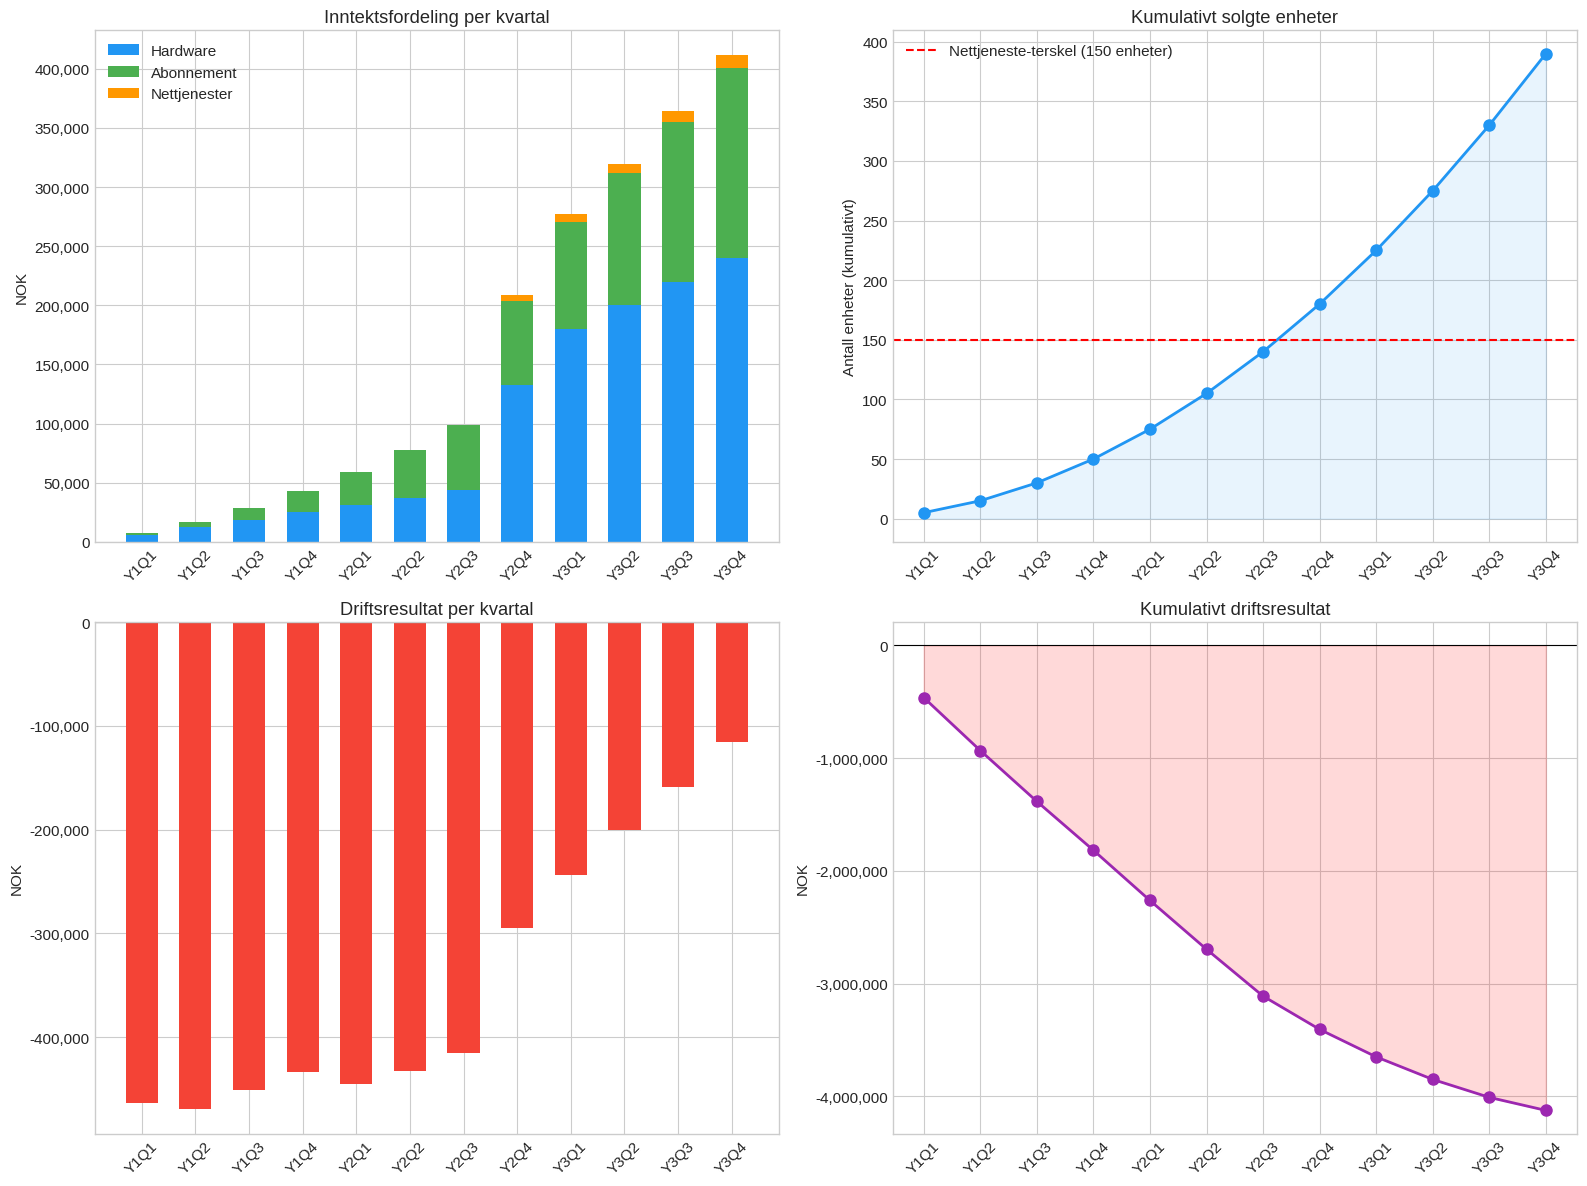

Figur lagret som 'budsjett_oversikt.png'


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Inntektsfordeling ---
ax = axes[0, 0]
x = np.arange(n_kv)
w = 0.6
ax.bar(x, hw_inntekt, w, label='Hardware', color='#2196F3')
ax.bar(x, abo_inntekt, w, bottom=hw_inntekt, label='Abonnement', color='#4CAF50')
ax.bar(x, nett_inntekt, w, 
       bottom=[hw_inntekt[i]+abo_inntekt[i] for i in range(n_kv)], 
       label='Nettjenester', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(kvartaler, rotation=45)
ax.set_ylabel('NOK')
ax.set_title('Inntektsfordeling per kvartal')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# --- Plot 2: Kumulativt antall enheter + terskel ---
ax = axes[0, 1]
ax.plot(x, kumulativ, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.axhline(y=NETT_TERSKEL_ENHETER, color='red', linestyle='--', linewidth=1.5, 
           label=f'Nettjeneste-terskel ({NETT_TERSKEL_ENHETER} enheter)')
ax.fill_between(x, 0, kumulativ, alpha=0.1, color='#2196F3')
ax.set_xticks(x)
ax.set_xticklabels(kvartaler, rotation=45)
ax.set_ylabel('Antall enheter (kumulativt)')
ax.set_title('Kumulativt solgte enheter')
ax.legend()

# --- Plot 3: Driftsresultat per kvartal ---
ax = axes[1, 0]
colors = ['#f44336' if v < 0 else '#4CAF50' for v in df['Driftsresultat']]
ax.bar(x, df['Driftsresultat'], w, color=colors)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(kvartaler, rotation=45)
ax.set_ylabel('NOK')
ax.set_title('Driftsresultat per kvartal')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# --- Plot 4: Kumulativt driftsresultat ---
ax = axes[1, 1]
ax.plot(x, df['Kumulativt driftsresultat'], 'o-', color='#9C27B0', linewidth=2, markersize=8)
ax.fill_between(x, 0, df['Kumulativt driftsresultat'], 
                where=[v >= 0 for v in df['Kumulativt driftsresultat']], 
                alpha=0.15, color='green')
ax.fill_between(x, 0, df['Kumulativt driftsresultat'], 
                where=[v < 0 for v in df['Kumulativt driftsresultat']], 
                alpha=0.15, color='red')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(kvartaler, rotation=45)
ax.set_ylabel('NOK')
ax.set_title('Kumulativt driftsresultat')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('budsjett_oversikt.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figur lagret som 'budsjett_oversikt.png'")

## 5. Scenarioanalyse: Abonnement vs Revenue Share

Sammenligner ulike prismodeller.

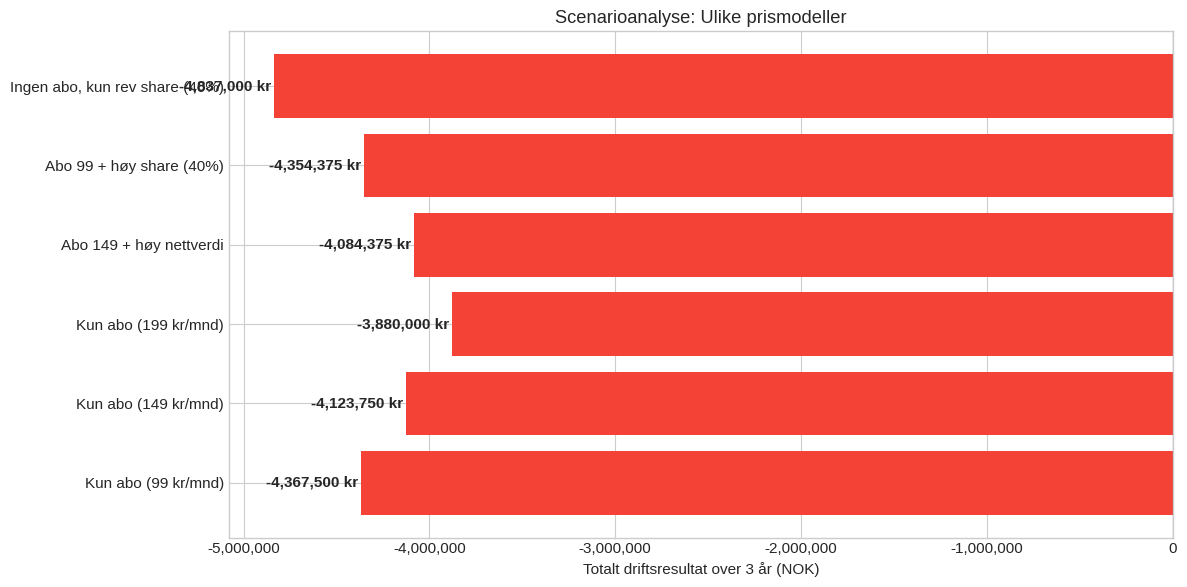

In [6]:
def beregn_totalt_driftsresultat(abo_mnd, nett_inntekt_kwh, rev_share_selskap):
    """Beregner totalt driftsresultat over 3 år for gitte parametere."""
    total = 0
    kum = np.cumsum(ENHETER_SOLGT)
    
    for i in range(n_kv):
        # HW-inntekt (samme som før)
        kum_start = kum[i] - ENHETER_SOLGT[i]
        ea = max(0, min(EARLY_ADOPTER_GRENSE, kum[i]) - kum_start)
        ea = max(0, ea)
        norm = max(0, ENHETER_SOLGT[i] - ea)
        hw = ea * EARLY_ADOPTER_PRIS + norm * NORMAL_PRIS
        
        # Abo
        eks = kum[i] - ENHETER_SOLGT[i]
        abo = (eks * 3 + ENHETER_SOLGT[i] * 1.5) * abo_mnd
        
        # Nett
        nett = 0
        if kum[i] >= NETT_TERSKEL_ENHETER:
            tilgj = kum[i] * KWH_PER_ENHET * TILGJENGELIGHET
            nett = tilgj * nett_inntekt_kwh / 4 * rev_share_selskap
        
        # Kostnader
        mk = MATERIALKOST_START if kum[i] <= EARLY_ADOPTER_GRENSE else MATERIALKOST_VOLUM
        var = ENHETER_SOLGT[i] * mk
        
        total += hw + abo + nett - var - faste_kost[i]
    
    return total

# Scenarioer
scenarioer = {
    'Kun abo (99 kr/mnd)': beregn_totalt_driftsresultat(99, 50, 0.30),
    'Kun abo (149 kr/mnd)': beregn_totalt_driftsresultat(149, 50, 0.30),
    'Kun abo (199 kr/mnd)': beregn_totalt_driftsresultat(199, 50, 0.30),
    'Abo 149 + høy nettverdi': beregn_totalt_driftsresultat(149, 100, 0.30),
    'Abo 99 + høy share (40%)': beregn_totalt_driftsresultat(99, 50, 0.40),
    'Ingen abo, kun rev share (40%)': beregn_totalt_driftsresultat(0, 50, 0.40),
}

fig, ax = plt.subplots(figsize=(12, 6))
names = list(scenarioer.keys())
values = list(scenarioer.values())
colors = ['#4CAF50' if v >= 0 else '#f44336' for v in values]
bars = ax.barh(names, values, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Totalt driftsresultat over 3 år (NOK)')
ax.set_title('Scenarioanalyse: Ulike prismodeller')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

for bar, val in zip(bars, values):
    ax.text(val + (15000 if val >= 0 else -15000), bar.get_y() + bar.get_height()/2, 
            f'{val:,.0f} kr', va='center', ha='left' if val >= 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.savefig('scenario_sammenligning.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Detaljert driftsbudsjett (til oppgaven)

Formatert slik det kan brukes direkte i rapporten.

In [7]:
# Bygg det formelle driftsbudsjettet
budsjett_data = {
    'Driftsinntekter:': [''] * n_kv,
    '  Inntekter (hardware-salg)': hw_inntekt,
    '  Abonnementsinntekter': abo_inntekt,
    '  Nettjeneste-inntekter': nett_inntekt,
    'Sum Driftsinntekter': [hw_inntekt[i] + abo_inntekt[i] + nett_inntekt[i] for i in range(n_kv)],
    ' ': [''] * n_kv,
    'Variable kostnader:': [''] * n_kv,
    '  Materialer (styringsboks)': var_kost,
    'Sum Variable kostnader': var_kost,
    'DEKNINGSBIDRAG': [hw_inntekt[i] + abo_inntekt[i] + nett_inntekt[i] - var_kost[i] for i in range(n_kv)],
    '  ': [''] * n_kv,
    'Indirekte kostnader:': [''] * n_kv,
    '  Lønn': lonn,
    '  Strøm': [STROM_PR_KVARTAL] * n_kv,
    '  Leie av kontorlokaer': KONTOR_PR_KVARTAL,
    '  Regnskap/revisjon/bank': [REGNSKAP_PR_KVARTAL] * n_kv,
    '  Sky/infrastruktur': SKY_PR_KVARTAL,
    '  Andre driftskostnader': ANDRE_DRIFT_PR_KVARTAL,
    '  Markedsføring': MARKED_PR_KVARTAL,
    '  Forsikringer': [FORSIKRING_PR_KVARTAL] * n_kv,
    'Sum indirekte kostnader': faste_kost,
    '   ': [''] * n_kv,
    'DRIFTSRESULTAT': df['Driftsresultat'].tolist(),
}

budsjett_df = pd.DataFrame(budsjett_data, index=kvartaler).T

# Legg til total-kolonne
totals = []
for idx, row in budsjett_df.iterrows():
    vals = pd.to_numeric(row, errors='coerce')
    if vals.notna().any():
        totals.append(vals.sum())
    else:
        totals.append('')
budsjett_df['TOTALT'] = totals

def format_cell(x):
    if isinstance(x, str) and x == '':
        return ''
    try:
        return f"{float(x):,.0f}"
    except:
        return str(x)

styled_budsjett = budsjett_df.style.format(format_cell).set_caption(
    "Driftsbudsjett for oppstartsbedriften — 3 år, kvartalsvis"
)
styled_budsjett

,Y1Q1,Y1Q2,Y1Q3,Y1Q4,Y2Q1,Y2Q2,Y2Q3,Y2Q4,Y3Q1,Y3Q2,Y3Q3,Y3Q4,TOTALT
Driftsinntekter:,,,,,,,,,,,,,
Inntekter (hardware-salg),"6,250","12,500","18,750","25,000","31,250","37,500","43,750","132,500","180,000","200,000","220,000","240,000","1,147,500"
Abonnementsinntekter,"1,118","4,470","10,058","17,880","27,938","40,230","54,758","71,520","90,518","111,750","135,218","160,920","726,375"
Nettjeneste-inntekter,0,0,0,0,0,0,0,"5,062","6,328","7,734","9,281","10,969","39,375"
Sum Driftsinntekter,"7,368","16,970","28,808","42,880","59,188","77,730","98,508","209,082","276,846","319,484","364,499","411,889","1,913,250"
,,,,,,,,,,,,,
Variable kostnader:,,,,,,,,,,,,,
Materialer (styringsboks),"6,000","12,000","18,000","24,000","30,000","36,000","42,000","32,000","36,000","40,000","44,000","48,000","368,000"
Sum Variable kostnader,"6,000","12,000","18,000","24,000","30,000","36,000","42,000","32,000","36,000","40,000","44,000","48,000","368,000"
DEKNINGSBIDRAG,"1,368","4,970","10,808","18,880","29,188","41,730","56,508","177,082","240,846","279,484","320,499","363,889","1,545,250"


## 7. Nøkkeltall og oppsummering

In [8]:
print("=" * 60)
print("NØKKELTALL — OPPSUMMERING")
print("=" * 60)
print(f"")
print(f"Investeringsutlegg (G₀):        {G0_TOTAL:>12,.0f} kr")
print(f"")
print(f"--- Salg ---")
print(f"Totalt solgte enheter:          {sum(ENHETER_SOLGT):>12,}")
print(f"  År 1:                         {sum(ENHETER_SOLGT[:4]):>12,}")
print(f"  År 2:                         {sum(ENHETER_SOLGT[4:8]):>12,}")
print(f"  År 3:                         {sum(ENHETER_SOLGT[8:]):>12,}")
print(f"")
print(f"--- Inntekter (3 år) ---")
print(f"Hardware-salg:                  {sum(hw_inntekt):>12,.0f} kr")
print(f"Abonnement:                     {sum(abo_inntekt):>12,.0f} kr")
print(f"Nettjenester:                   {sum(nett_inntekt):>12,.0f} kr")
print(f"Sum inntekter:                  {sum(hw_inntekt)+sum(abo_inntekt)+sum(nett_inntekt):>12,.0f} kr")
print(f"")
print(f"--- Kostnader (3 år) ---")
print(f"Variable kostnader:             {sum(var_kost):>12,.0f} kr")
print(f"Faste kostnader:                {sum(faste_kost):>12,.0f} kr")
print(f"Sum kostnader:                  {sum(var_kost)+sum(faste_kost):>12,.0f} kr")
print(f"")
print(f"--- Resultat ---")
print(f"Totalt driftsresultat (3 år):   {df['Driftsresultat'].sum():>12,.0f} kr")
print(f"")
print(f"--- Milepæler ---")
terskel_kv = next((i for i in range(n_kv) if kumulativ[i] >= NETT_TERSKEL_ENHETER), None)
if terskel_kv is not None:
    print(f"Nettjeneste-terskel nådd:       {kvartaler[terskel_kv]}  ({kumulativ[terskel_kv]} enheter)")
else:
    print(f"Nettjeneste-terskel IKKE nådd i perioden!")

breakeven_kv = next((i for i in range(n_kv) if df['Driftsresultat'].iloc[i] > 0), None)
if breakeven_kv is not None:
    print(f"Første kvartal med overskudd:   {kvartaler[breakeven_kv]}")
else:
    print(f"Ikke lønnsomt i perioden (på kvartalsbasis)")
print("=" * 60)

NØKKELTALL — OPPSUMMERING

Investeringsutlegg (G₀):             750,000 kr

--- Salg ---
Totalt solgte enheter:                   390
  År 1:                                   50
  År 2:                                  130
  År 3:                                  210

--- Inntekter (3 år) ---
Hardware-salg:                     1,147,500 kr
Abonnement:                          726,375 kr
Nettjenester:                         39,375 kr
Sum inntekter:                     1,913,250 kr

--- Kostnader (3 år) ---
Variable kostnader:                  368,000 kr
Faste kostnader:                   5,669,000 kr
Sum kostnader:                     6,037,000 kr

--- Resultat ---
Totalt driftsresultat (3 år):     -4,123,750 kr

--- Milepæler ---
Nettjeneste-terskel nådd:       Y2Q4  (180 enheter)
Ikke lønnsomt i perioden (på kvartalsbasis)


## 8. Neste steg

**TODO:**
- [ ] Juster parametere basert på gruppediskusjon
- [ ] Sett opp likviditetsbudsjett (innbetalinger vs utbetalinger, tidsforskyving)
- [ ] Eksporter til Excel-malen
- [ ] NNV/IRR-analyse (investeringsanalyse)
- [ ] Sensitivitetsanalyse
- [ ] Skriv noter til budsjettet